In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Model parameters
N = 1e5
i0 = 10.0
R0 = 1.5

def f(t, i):
    """RHS of di/dt = (R0-1) i - R0 i^2 / N"""
    return (R0 - 1) * i - R0 * i**2 / N

def i_exact(t, t0=0.0, i_t0=i0):
    """Closed-form solution of the SIS ODE, started from i(t0) = i_t0."""
    K = N * (1 - 1 / R0)
    tau = t - t0
    return K * i_t0 * np.exp((R0 - 1) * tau) / (
        K + i_t0 * (np.exp((R0 - 1) * tau) - 1)
    )

# Single-step functions
def euler_step(f, t, y, h):
    return y + h * f(t, y)

def rk2_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h, y + h * k1)
    return y + h / 2 * (k1 + k2)

def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h / 2, y + h / 2 * k1)
    k3 = f(t + h / 2, y + h / 2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

STEPPERS = {
    "Euler": euler_step,
    "RK2": rk2_step,
    "RK4": rk4_step
}

# Generic integrator for the global error
def integrate(step_fn, f, y0, T, M):
    h = T / M
    t = np.linspace(0, T, M + 1)
    y = np.empty(M + 1)
    y[0] = y0

    for j in range(M):
        y[j + 1] = step_fn(f, t[j], y[j], h)

    return t, y

# M values: log-spaced integers from 100 to 2000
# h = 20/M, so h runs from 0.2 down to 0.01
Ms = np.round(
    np.logspace(np.log10(100), np.log10(2000), 10)
).astype(int)

hs = 20.0 / Ms

## 1.1(b) Local error

The local error is the error from a single step started on the exact solution. For each $t_0 \in \{2, 10, 20\}$, I start from the exact value $i(t_0)$ given by Eq. (3). I take one step of size $h$ with Euler, RK2, and RK4, and compare the numerical result with the exact value $i(t_0+h)$:

$$
e(h) =
\left|
i_{\mathrm{num}}(t_0+h)
-
i_{\mathrm{exact}}(t_0+h)
\right|.
$$

The step sizes are $h=20/M$, with $M$ log-spaced integers from 100 to 2000, so $h$ runs from 0.2 down to 0.01.

For each method, I fit

$$
\log e = a\log h+b
$$

using `scipy.stats.linregress`. The fitted slope $a$ indicates the power of $h$ in the local error.

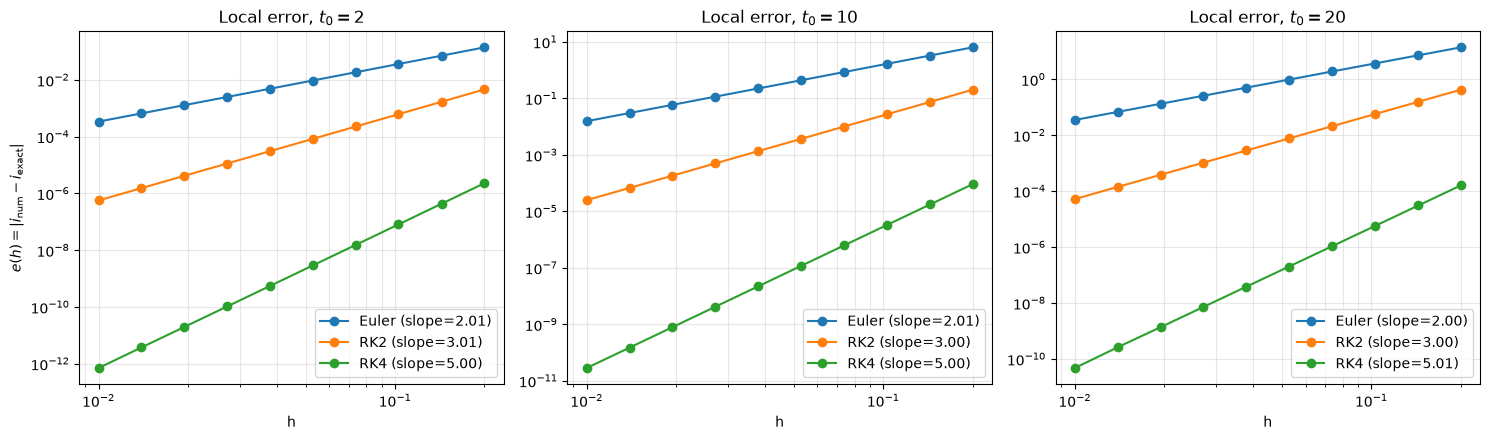

Question 1.1(b): Local error slopes

t0 = 2
    Euler: slope = 2.010, R^2 = 1.00000
    RK2: slope = 3.007, R^2 = 1.00000
    RK4: slope = 5.005, R^2 = 1.00000

t0 = 10
    Euler: slope = 2.008, R^2 = 1.00000
    RK2: slope = 3.004, R^2 = 1.00000
    RK4: slope = 5.002, R^2 = 1.00000

t0 = 20
    Euler: slope = 1.996, R^2 = 1.00000
    RK2: slope = 3.003, R^2 = 1.00000
    RK4: slope = 5.010, R^2 = 1.00000


In [3]:
# Question 1.1(b): Local error

t0_values = [2, 10, 20]

local_results = {
    t0: {name: np.empty(len(hs)) for name in STEPPERS}
    for t0 in t0_values
}

# Calculate local errors
for t0 in t0_values:
    # Start exactly on the analytical solution
    y_t0 = i_exact(t0)

    for k, h in enumerate(hs):

        # Exact solution at t0 + h
        y_true_next = i_exact(
            t0 + h,
            t0=t0,
            i_t0=y_t0
        )

        # One numerical step with each method
        for name, step_fn in STEPPERS.items():
            y_num_next = step_fn(
                f,
                t0,
                y_t0,
                h
            )

            local_results[t0][name][k] = abs(
                y_num_next - y_true_next
            )

# Fit log(e) = a log(h) + b
local_slopes = {
    t0: {}
    for t0 in t0_values
}

for t0 in t0_values:
    for name in STEPPERS:
        eps = local_results[t0][name]

        res = linregress(
            np.log(hs),
            np.log(eps)
        )

        local_slopes[t0][name] = (
            res.slope,
            res.intercept,
            res.rvalue**2
        )

# Plot local errors
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
    sharey=False
)

for ax, t0 in zip(axes, t0_values):

    for name in STEPPERS:

        eps = local_results[t0][name]

        slope, intercept, r2 = local_slopes[t0][name]

        ax.loglog(
            hs,
            eps,
            "o-",
            label=f"{name} (slope={slope:.2f})"
        )

    ax.set_xlabel("h")
    ax.set_title(f"Local error, $t_0={t0}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

axes[0].set_ylabel(
    r"$e(h)=|i_{\mathrm{num}}-i_{\mathrm{exact}}|$"
)

plt.tight_layout()

plt.savefig(
    "local_error.png",
    dpi=150
)

plt.show()

# Print fitted slopes
print("Question 1.1(b): Local error slopes")

for t0 in t0_values:

    print(f"\nt0 = {t0}")

    for name in STEPPERS:

        slope, intercept, r2 = local_slopes[t0][name]

        print(
            f"    {name}: "
            f"slope = {slope:.3f}, "
            f"R^2 = {r2:.5f}"
        )

#### Interpretation

For a method of order $p$, the local truncation error is expected to behave like

$$
e(h)=O(h^{p+1}).
$$

Therefore, on a log-log plot, we expect the fitted slope to be approximately $p+1$.

The expected slopes are:

- **Euler:** slope $\approx 2$, so the local error is $O(h^2)$ and the method is first-order.
- **RK2:** slope $\approx 3$, so the local error is $O(h^3)$ and the method is second-order.
- **RK4:** slope $\approx 5$, so the local error is $O(h^5)$ and the method is fourth-order.

The numerical slopes printed above should be close to these theoretical values.

A higher-order method reduces its error more quickly as $h$ decreases. Therefore, RK4 should have the smallest local error, followed by RK2 and then Euler.

**Dependence on $t_0$:** The slopes should be approximately the same for $t_0=2$, $10$, and $20$. This is expected because the order of convergence is a property of the numerical method rather than the starting point. However, the magnitude of the error can depend on $t_0$, because the error constants depend on derivatives of the exact solution. Thus, the curves can have different vertical positions while having approximately the same slope.

The values of $R^2$ printed above should also be close to 1, indicating that the errors approximately follow the expected power-law relationship over the tested range of $h$.

## 1.1(c) Global error

For the global error, I integrate the solution from $t=0$ to $T=20$ using $M$ steps. I then compare the numerical solution at the final time with the exact solution:

$$
E(h)=|i_M-i(T)|.
$$

The same values of $M$ and $h=20/M$ are used as in part (b).

For each method, I again fit

$$
\log E = a\log h+b
$$

using `scipy.stats.linregress`. The fitted slope gives the observed order of the global error.

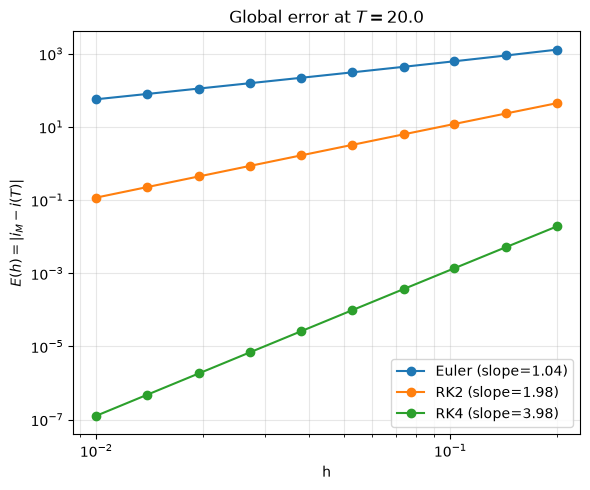

Question 1.1(c): Global error slopes
    Euler: slope = 1.039, R^2 = 0.99977
    RK2: slope = 1.985, R^2 = 0.99999
    RK4: slope = 3.980, R^2 = 1.00000


In [4]:
# Question 1.1(c): Global error

T = 20.0

global_results = {
    name: np.empty(len(Ms))
    for name in STEPPERS
}

# Exact solution at the final time
y_true = i_exact(T)

# Calculate global errors
for k, M in enumerate(Ms):

    for name, step_fn in STEPPERS.items():

        t, y = integrate(
            step_fn,
            f,
            i0,
            T,
            M
        )

        global_results[name][k] = abs(
            y[-1] - y_true
        )

# Fit log(E) = a log(h) + b
global_slopes = {}

for name in STEPPERS:

    eps = global_results[name]

    res = linregress(
        np.log(hs),
        np.log(eps)
    )

    global_slopes[name] = (
        res.slope,
        res.intercept,
        res.rvalue**2
    )

# Plot global errors
plt.figure(figsize=(6, 5))

for name in STEPPERS:

    eps = global_results[name]

    slope, intercept, r2 = global_slopes[name]

    plt.loglog(
        hs,
        eps,
        "o-",
        label=f"{name} (slope={slope:.2f})"
    )

plt.xlabel("h")
plt.ylabel(
    r"$E(h)=|i_M-i(T)|$"
)

plt.title(f"Global error at $T={T}$")

plt.grid(
    True,
    which="both",
    alpha=0.3
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "global_error.png",
    dpi=150
)

plt.show()

# Print fitted global slopes
print("Question 1.1(c): Global error slopes")

for name in STEPPERS:

    slope, intercept, r2 = global_slopes[name]

    print(
        f"    {name}: "
        f"slope = {slope:.3f}, "
        f"R^2 = {r2:.5f}"
    )

#### Interpretation and comparison

The expected global error for a method of order $p$ is

$$
E(h)=O(h^p).
$$

This means that the global error should have a slope approximately one lower than the local error slope.

The expected global slopes are therefore:

- **Euler:** approximately $1$
- **RK2:** approximately $2$
- **RK4:** approximately $4$

This is because each step has a local error of $O(h^{p+1})$. Since reaching $T$ requires approximately $T/h$ steps, the accumulated error behaves approximately as

$$
\frac{T}{h}O(h^{p+1})
=
O(h^p).
$$

Therefore, the global error is one power of $h$ lower than the local error.

The numerical slopes printed above should be close to these theoretical values. Small differences from the exact theoretical orders are expected because the tested step sizes are finite and the largest values of $h$ may not yet be fully in the asymptotic regime.

The global-error plot also demonstrates the advantage of higher-order methods. RK4 should give the smallest error for a given step size, followed by RK2 and then Euler. This makes RK4 the most accurate of the three methods for this problem.

Since RK4 provides fourth-order global accuracy, it will be used for the remaining numerical experiments in the assignment.